<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ConvLSTM_optimizations/1lstm_1hidden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Dense, Flatten, Dropout, Input
from sklearn.preprocessing import RobustScaler
from datetime import timedelta

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60
N_TIMESTEPS = 7
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Manual "Randomly Picked" Hyperparameters
FIXED_LR = 0.001
FIXED_FILTERS = 64
FIXED_KERNEL_SIZE = (1, 2) # Moving across features
FIXED_EPOCHS = 30
FIXED_BATCH_SIZE = 32

In [2]:
# ================== MODEL BUILDING ==================
def build_convlstm_model(n_timesteps, n_features, filters, kernel_size, lr):
    """
    Builds a ConvLSTM2D model.
    Input shape for ConvLSTM2D: (samples, time, rows, cols, channels)
    We will treat features as 'cols' and rows as 1.
    """
    model = Sequential([
        Input(shape=(n_timesteps, 1, n_features, 1)),
        ConvLSTM2D(
            filters=filters,
            kernel_size=kernel_size,
            padding='same',
            return_sequences=False,
            activation='relu'
        ),
        Flatten(),
        Dense(64, activation='relu'), # Intermediate dense layer
        Dense(1, activation='linear')  # Output layer
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def reshape_for_convlstm(X):
    """
    Reshapes (samples, timesteps, features)
    to (samples, timesteps, 1, features, 1)
    """
    return X.reshape((X.shape[0], X.shape[1], 1, X.shape[2], 1))



In [3]:
# ================== TRAINING LOGIC ==================
def train_and_plot_convlstm(df_center, center_name):
    # Basic Feature Engineering (Lags)
    df_center = df_center.sort_values('Date').reset_index(drop=True)
    for col in TARGET_RAW_COLS:
        for lag in [1, 7]:
            df_center[f'{col}_lag{lag}'] = df_center[col].shift(lag)
    df_center = df_center.fillna(0)

    # Split
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train = df_center[df_center['Date'] < test_start_date].copy()
    df_test = df_center[df_center['Date'] >= test_start_date].copy()

    feature_cols = [c for c in df_train.columns if c not in ['Date'] + TARGET_RAW_COLS]
    scaler = RobustScaler()

    X_train_scaled = scaler.fit_transform(df_train[feature_cols])
    X_test_scaled = scaler.transform(df_test[feature_cols])

    for target_col in TARGET_RAW_COLS:
        print(f"\n--- Training ConvLSTM for {center_name} - {target_col} ---")

        # Create Sequences
        y_train_raw = df_train[target_col].values
        X_seq_train, y_seq_train = [], []
        for i in range(len(X_train_scaled) - N_TIMESTEPS):
            X_seq_train.append(X_train_scaled[i:i+N_TIMESTEPS])
            y_seq_train.append(y_train_raw[i+N_TIMESTEPS])

        X_seq_train = np.array(X_seq_train)
        y_seq_train = np.array(y_seq_train)

        # Reshape for ConvLSTM (5D)
        X_seq_train_5d = reshape_for_convlstm(X_seq_train)

        # Build and Fit
        model = build_convlstm_model(
            N_TIMESTEPS,
            X_seq_train.shape[2],
            FIXED_FILTERS,
            FIXED_KERNEL_SIZE,
            FIXED_LR
        )

        model.fit(
            X_seq_train_5d, y_seq_train,
            epochs=FIXED_EPOCHS,
            batch_size=FIXED_BATCH_SIZE,
            verbose=1,
            validation_split=0.1
        )

        # Prepare Test Data
        # Concatenate last part of train to start of test to get full test sequences
        X_combined = np.vstack([X_train_scaled[-N_TIMESTEPS:], X_test_scaled])
        X_seq_test = []
        for i in range(len(X_combined) - N_TIMESTEPS):
            X_seq_test.append(X_combined[i:i+N_TIMESTEPS])

        X_seq_test = reshape_for_convlstm(np.array(X_seq_test))
        y_preds = model.predict(X_seq_test).flatten()

        # Plotting
        plt.figure(figsize=(10, 4))
        plt.plot(df_test['Date'][:len(y_preds)], df_test[target_col][:len(y_preds)], label='Actual')
        plt.plot(df_test['Date'][:len(y_preds)], y_preds, label='ConvLSTM Prediction', linestyle='--')
        plt.title(f"{center_name} {target_col}: ConvLSTM Results")
        plt.legend()
        plt.show()



--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_BreakFast ---
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - loss: 949473.5625 - mae: 793.6602 - val_loss: 7323928.5000 - val_mae: 2393.3096
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 934979.2500 - mae: 785.2466 - val_loss: 5400728.5000 - val_mae: 1948.7347
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 709419.3750 - mae: 638.8715 - val_loss: 2525249.2500 - val_mae: 1076.1183
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 483362.0000 - mae: 504.2409 - val_loss: 1981132.0000 - val_mae: 917.5649
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 296320.3438 - mae: 438.6481 - val_loss: 3449013.0000 - val_mae: 1383.6544
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 339183.5312 - mae: 437.8603 - val_loss: 3012416.5000 - val_mae: 1241.7336
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 318241.0000 - mae: 416.3966 - val_loss: 2490498.0000 - val_mae: 1070.735

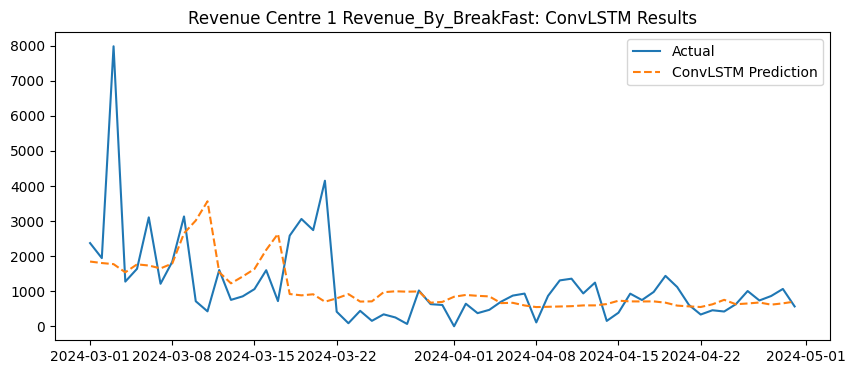


--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_Dinner ---
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - loss: 7518411.5000 - mae: 2450.0483 - val_loss: 27641444.0000 - val_mae: 5059.2007
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7473960.5000 - mae: 2441.6160 - val_loss: 24292700.0000 - val_mae: 4719.1348
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6668153.5000 - mae: 2178.4580 - val_loss: 28286550.0000 - val_mae: 4250.8789
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2035931.0000 - mae: 1005.2867 - val_loss: 5015757.5000 - val_mae: 1660.4095
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1458042.0000 - mae: 874.1856 - val_loss: 3261854.5000 - val_mae: 1410.9288
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1452600.1250 - mae: 835.3328 - val_loss: 3074402.0000 - val_mae: 1390.8499
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1347326.2500 - mae: 851.7863 - val_loss: 3679645.2500 - val_m

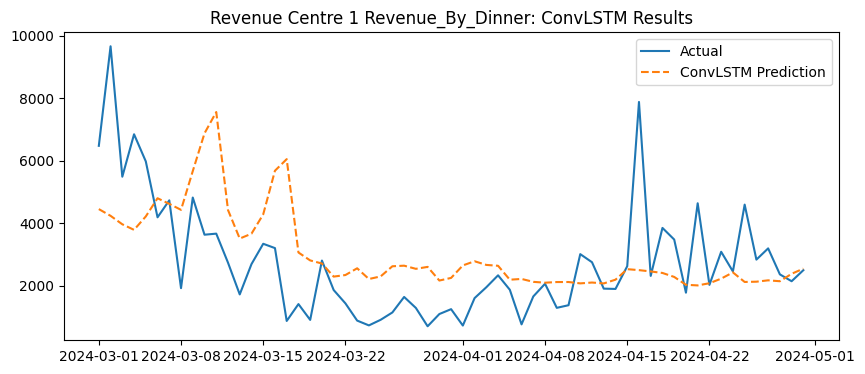


--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_Lunch ---
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - loss: 586999.8125 - mae: 607.4557 - val_loss: 3787324.2500 - val_mae: 1680.5930
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 580687.8125 - mae: 602.8548 - val_loss: 3306981.0000 - val_mae: 1539.5894
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 476679.2188 - mae: 506.0188 - val_loss: 1059463.2500 - val_mae: 861.8214
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 260167.6719 - mae: 350.4353 - val_loss: 1120368.0000 - val_mae: 855.2063
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 231352.9531 - mae: 356.1107 - val_loss: 1495707.7500 - val_mae: 977.3153
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 221757.1719 - mae: 341.7293 - val_loss: 1458521.7500 - val_mae: 966.4709
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 227570.8125 - mae: 345.2208 - val_loss: 1423915.6250 - val_mae: 955.2684
Epoch 

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 869ms/step


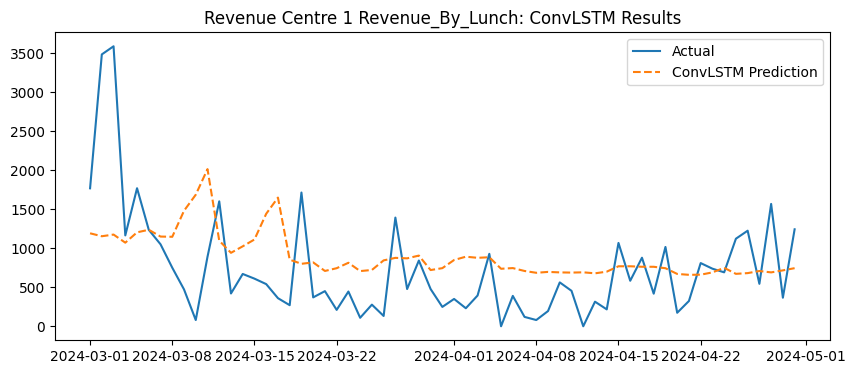

In [4]:
# ================== EXECUTION ==================
if __name__ == '__main__':
    # Usage Example
    try:
        # Assuming sheet 0 is the data
        df = pd.read_excel(INPUT_FILE_NAME, sheet_name=0)
        df['Date'] = pd.to_datetime(df['Date'])
        train_and_plot_convlstm(df, "Revenue Centre 1")
    except Exception as e:
        print(f"Error: {e}")